In [1]:
## IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

## LOAD DATA

snp_raw = pd.read_csv("data/compustat_fundamental_annual.csv") # raw data from Compustat
sp500 = pd.read_csv("data/constituents.csv") # data of S&P 500 constituents

- gvkey: company key, conm: company name

In [2]:
# snp_raw["sic"].value_counts()

# drop costat column since it is not relevant to our analysis
snp_raw.drop("costat", inplace=True, axis=1)
# drop CAD since we dont want to convert it to USD
snp_raw.drop(snp_raw[snp_raw["curcd"] == "CAD"].index, inplace=True, axis=0)
# drop curcd column since we only have USD data
snp_raw.drop("curcd", inplace=True, axis=1)
# drop datafmt, indfmt and consol columns since they are not relevant to our analysis
snp_raw.drop(["datafmt", "indfmt", "consol"], inplace=True, axis=1)
# drop fyr column since we can calculate fiscal year end date using datadate column
snp_raw.drop("fyr", inplace=True, axis=1)

In [3]:
snp_raw.head()

,gvkey,datadate,conm,tic,cik,naics,sic,at,ceq,che,...,ebit,ebitda,gp,ni,revt,sale,capx,oancf,csho,prcc_f
0,1004,31/5/2009,AAR CORP,AIR,1750.0,423860.0,5080,1377.511,656.895,112.505,...,125.529,166.080,313.299,78.651,1423.976,1423.976,27.535,64.451,38.884,14.70
1,1004,31/5/2010,AAR CORP,AIR,1750.0,423860.0,5080,1501.042,746.906,79.370,...,95.415,134.345,286.249,44.628,1352.151,1352.151,28.855,153.156,39.484,19.70
2,1004,31/5/2011,AAR CORP,AIR,1750.0,423860.0,5080,1703.727,835.845,57.433,...,137.016,196.312,367.711,69.826,1775.782,1775.782,124.879,108.598,39.781,26.39
3,1004,31/5/2012,AAR CORP,AIR,1750.0,423860.0,5080,2195.653,864.649,67.720,...,142.360,222.693,412.090,67.723,2074.498,2074.498,91.218,94.217,40.273,12.05
4,1004,31/5/2013,AAR CORP,AIR,1750.0,423860.0,5080,2136.900,918.600,75.300,...,136.600,245.200,452.600,55.000,2167.100,2167.100,37.600,162.900,39.382,20.06


In [4]:
# Check the first few rows
sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [5]:
# --------------------------------------------------
# 2. Remove companies under Financials sector
# --------------------------------------------------
sp500_nonfin = sp500[
    sp500["GICS Sector"] != "Financials"
].copy()

print("Original number of S&P 500 companies:", len(sp500))
print("After removing Financials:", len(sp500_nonfin))

Original number of S&P 500 companies: 503
After removing Financials: 427


In [6]:
# --------------------------------------------------
# 3. Remove banking-related companies using sub-industry keywords
# --------------------------------------------------
banking_keywords = [
    "bank",
    "banks",
    "banking",
    "financial",
    "insurance",
    "capital markets",
    "mortgage",
    "consumer finance",
    "diversified financial",
    "asset management",
    "investment banking",
    "brokerage"
]

pattern = "|".join(banking_keywords)

sp500_nonfin = sp500_nonfin[
    ~sp500_nonfin["GICS Sub-Industry"]
    .str.lower()
    .str.contains(pattern, na=False)
].copy()

print("After removing Financials and banking-related firms:", len(sp500_nonfin))

After removing Financials and banking-related firms: 427


In [7]:
# --------------------------------------------------
# 4. Create Yahoo Finance-compatible ticker
# --------------------------------------------------
sp500_nonfin["ticker_yahoo"] = (
    sp500_nonfin["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(".", "-", regex=False)
)

sp500_nonfin[["Symbol", "ticker_yahoo", "Security", "GICS Sector", "GICS Sub-Industry"]].head()

,Symbol,ticker_yahoo,Security,GICS Sector,GICS Sub-Industry
0,MMM,MMM,3M,Industrials,Industrial Conglomerates
1,AOS,AOS,A. O. Smith,Industrials,Building Products
2,ABT,ABT,Abbott Laboratories,Health Care,Health Care Equipment
3,ABBV,ABBV,AbbVie,Health Care,Biotechnology
4,ACN,ACN,Accenture,Information Technology,IT Consulting & Other Services


In [9]:
snp500_overall = pd.merge(snp_raw, sp500_nonfin, left_on="tic", right_on="ticker_yahoo", how="inner")
snp500_overall.drop(["tic", "Symbol"], inplace=True, axis=1)
snp500_overall.head()

,gvkey,datadate,conm,cik,naics,sic,at,ceq,che,dlc,...,csho,prcc_f,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,ticker_yahoo
0,1075,31/12/2009,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,11808.155,3316.109,145.378,431.408,...,101.435,36.58,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
1,1075,31/12/2010,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,12362.703,3683.327,110.188,648.479,...,108.770,41.45,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
2,1075,31/12/2011,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,13111.018,3821.850,33.583,477.435,...,109.246,48.18,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
3,1075,31/12/2012,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,13379.615,3972.806,26.202,215.003,...,109.743,50.98,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW
4,1075,31/12/2013,PINNACLE WEST CAPITAL CORP,764622.0,2211.0,4911,13508.686,4194.470,9.526,693.549,...,110.182,52.92,Pinnacle West Capital,Utilities,Multi-Utilities,"Phoenix, Arizona",1999-10-04,764622,1985,PNW


In [10]:
snp500_overall.to_csv("data/snp500_merged.csv", index=False)

In [11]:
# checking specific rows to confirm missing values are handled correctly
copy = snp500_overall.iloc[6840:6845].copy()
## we want to remove rows with more than 25% missing values, so we check rows around the 25% threshold
cleaned = copy[copy.isna().mean(axis=1) <= 0.25]
# printed copy and cleaned to confirm that the correct rows are removed

In [12]:
snp500_overall_cleaned = snp500_overall[snp500_overall.isna().mean(axis=1) <= 0.25]
print("Original number of rows:", len(snp500_overall))
print("Number of rows after cleaning:", len(snp500_overall_cleaned))
print("Number of rows removed:", len(snp500_overall) - len(snp500_overall_cleaned))

Original number of rows: 6878
Number of rows after cleaning: 6846
Number of rows removed: 32


Note: cross checked with excel, all 32 rows of empty data was removed

In [13]:
snp500_overall_cleaned.to_csv("data/snp500_cleaned.csv", index=False)

In [18]:
import pandas as pd
import numpy as np
import yfinance as yf
import time

# --------------------------------------------------
# 1. Load cleaned S&P 500 non-financial data
# --------------------------------------------------

snp500_cleaned = pd.read_csv("data/snp500_cleaned.csv")

tickers = (
    snp500_cleaned["ticker_yahoo"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .unique()
    .tolist()
)

tickers = sorted(tickers)

print("Number of tickers:", len(tickers))

# --------------------------------------------------
# 2. Download monthly adjusted prices from Yahoo Finance
# --------------------------------------------------

all_monthly_data = []
failed_tickers = []

for i, ticker in enumerate(tickers, start=1):
    try:
        print(f"Downloading {i}/{len(tickers)}: {ticker}")

        data = yf.download(
            ticker,
            start="2009-01-01",
            end="2025-12-31",
            interval="1mo",
            auto_adjust=True,
            progress=False,
            multi_level_index=False
        )

        if data.empty:
            print(f"No data found for: {ticker}")
            failed_tickers.append(ticker)
            continue

        # Reset index so Date becomes a column
        data = data.reset_index()

        # Keep only date and adjusted close price
        temp = data[["Date", "Close"]].copy()

        temp["ticker_yahoo"] = ticker
        temp = temp.rename(columns={
            "Date": "month",
            "Close": "adjusted_close"
        })

        temp["month"] = pd.to_datetime(temp["month"])

        # Calculate monthly return ticker by ticker
        temp["monthly_return"] = temp["adjusted_close"].pct_change()

        all_monthly_data.append(
            temp[["ticker_yahoo", "month", "adjusted_close", "monthly_return"]]
        )

        time.sleep(0.3)

    except Exception as e:
        print(f"Failed to download {ticker}: {e}")
        failed_tickers.append(ticker)

# --------------------------------------------------
# 3. Combine all downloaded monthly data
# --------------------------------------------------

monthly_stock_data = pd.concat(all_monthly_data, ignore_index=True)

monthly_stock_data = monthly_stock_data.sort_values(
    ["ticker_yahoo", "month"]
).reset_index(drop=True)

# Save clean monthly return file
monthly_stock_data.to_csv("data/yahoo_monthly_stock_returns_clean.csv", index=False)

# Save failed tickers
failed_df = pd.DataFrame({"failed_ticker": failed_tickers})
failed_df.to_csv("data/failed_yahoo_tickers.csv", index=False)

print("Monthly stock return file saved as: data/yahoo_monthly_stock_returns_clean.csv")
print("Failed ticker file saved as: data/failed_yahoo_tickers.csv")
print("Number of failed tickers:", len(failed_tickers))

# --------------------------------------------------
# 4. Validation checks
# --------------------------------------------------

print("Shape:", monthly_stock_data.shape)

print("\nDate range:")
print(monthly_stock_data["month"].min(), "to", monthly_stock_data["month"].max())

print("\nNumber of tickers downloaded:")
print(monthly_stock_data["ticker_yahoo"].nunique())

print("\nColumns:")
print(monthly_stock_data.columns)

print("\nSample:")
monthly_stock_data.head(20)

Number of tickers: 423


$FDXF: possibly delisted; no price data found  (1mo 2009-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1230786000, endDate = 1767157200")

1 Failed download:
['FDXF']: possibly delisted; no price data found  (1mo 2009-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1230786000, endDate = 1767157200")


No data found for: FDXF
Monthly stock return file saved as: data/yahoo_monthly_stock_returns_clean.csv
Failed ticker file saved as: data/failed_yahoo_tickers.csv
Number of failed tickers: 1
Shape: (80285, 4)

Date range:
2009-01-01 00:00:00 to 2025-12-01 00:00:00

Number of tickers downloaded:
422

Columns:
Index(['ticker_yahoo', 'month', 'adjusted_close', 'monthly_return'], dtype='object')

Sample:


,ticker_yahoo,month,adjusted_close,monthly_return
0,A,2009-01-01,11.443537,NaN
1,A,2009-02-01,8.778863,-0.232854
2,A,2009-03-01,9.728268,0.108147
3,A,2009-04-01,11.557459,0.188028
4,A,2009-05-01,11.538473,-0.001643
5,A,2009-06-01,12.854987,0.114098
6,A,2009-07-01,14.696837,0.143279
7,A,2009-08-01,16.253870,0.105943
8,A,2009-09-01,17.614689,0.083723
9,A,2009-10-01,15.658914,-0.111031


In [19]:
# --------------------------------------------------
# 1. Load cleaned Compustat + S&P 500 file
# --------------------------------------------------

snp500_cleaned = pd.read_csv("data/snp500_cleaned.csv")

# --------------------------------------------------
# 2. Load failed Yahoo ticker file
# --------------------------------------------------

failed = pd.read_csv("data/failed_yahoo_tickers.csv")

failed_tickers = (
    failed["failed_ticker"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .tolist()
)

print("Failed tickers:", failed_tickers)
print("Number of failed tickers:", len(failed_tickers))

# --------------------------------------------------
# 3. Remove failed tickers from Compustat/S&P 500 file
# --------------------------------------------------

snp500_cleaned2 = snp500_cleaned[
    ~snp500_cleaned["ticker_yahoo"].isin(failed_tickers)
].copy()

print("Original rows:", len(snp500_cleaned))
print("Rows after removing failed tickers:", len(snp500_cleaned2))
print("Rows removed:", len(snp500_cleaned) - len(snp500_cleaned2))

print("Original unique tickers:", snp500_cleaned["ticker_yahoo"].nunique())
print("Cleaned unique tickers:", snp500_cleaned2["ticker_yahoo"].nunique())

# --------------------------------------------------
# 4. Save final cleaned file
# --------------------------------------------------

snp500_cleaned2.to_csv("data/snp500_cleaned_final.csv", index=False)

print("Final cleaned file saved as: data/snp500_cleaned_final.csv")

Failed tickers: ['FDXF']
Number of failed tickers: 1
Original rows: 6846
Rows after removing failed tickers: 6844
Rows removed: 2
Original unique tickers: 423
Cleaned unique tickers: 422
Final cleaned file saved as: data/snp500_cleaned_final.csv


In [23]:
# --------------------------------------------------
# Check ticker consistency between accounting and return files
# --------------------------------------------------

accounting_tickers = set(snp500_cleaned2["ticker_yahoo"].dropna().unique())
return_tickers = set(monthly_stock_data["ticker_yahoo"].dropna().unique())

print("Tickers in accounting file:", len(accounting_tickers))
print("Tickers in monthly return file:", len(return_tickers))

print("Accounting tickers not in return file:")
print(accounting_tickers - return_tickers)

print("Return tickers not in accounting file:")
print(return_tickers - accounting_tickers)

Tickers in accounting file: 422
Tickers in monthly return file: 422
Accounting tickers not in return file:
set()
Return tickers not in accounting file:
set()


In [40]:
import pandas as pd
import numpy as np

# ============================================================
# GENERATE FINANCIAL SIGNALS
# ============================================================

# ------------------------------------------------------------
# 1. Load final cleaned Compustat + S&P 500 data
# ------------------------------------------------------------

snp500 = pd.read_csv("data/snp500_cleaned_final.csv")

# Standardize column names
snp500.columns = snp500.columns.str.lower()

# Remove duplicate columns if any, e.g. duplicated cik
snp500 = snp500.loc[:, ~snp500.columns.duplicated()].copy()

# Convert datadate to datetime
snp500["datadate"] = pd.to_datetime(snp500["datadate"], errors="coerce")

# Create fiscal year if fyear is not available
if "fyear" not in snp500.columns:
    snp500["fyear"] = snp500["datadate"].dt.year

# ------------------------------------------------------------
# 2. Convert required columns to numeric
# ------------------------------------------------------------

numeric_cols = [
    "fyear", "at", "ceq", "seq", "txditc",
    "pstk", "pstkl", "pstkrv",
    "ni", "gp", "dlc", "dltt",
    "prcc_f", "csho"
]

for col in numeric_cols:
    if col in snp500.columns:
        snp500[col] = pd.to_numeric(snp500[col], errors="coerce")

# ------------------------------------------------------------
# 3. Sort data by company and fiscal year
# ------------------------------------------------------------

snp500 = snp500.sort_values(["ticker_yahoo", "fyear"]).copy()

# ------------------------------------------------------------
# 4. Construct book equity
# ------------------------------------------------------------

# Preferred stock:
# Use redemption value first, then liquidating value, then carrying value
snp500["preferred_stock"] = snp500["pstkrv"]

if "pstkl" in snp500.columns:
    snp500["preferred_stock"] = snp500["preferred_stock"].fillna(snp500["pstkl"])

if "pstk" in snp500.columns:
    snp500["preferred_stock"] = snp500["preferred_stock"].fillna(snp500["pstk"])

snp500["preferred_stock"] = snp500["preferred_stock"].fillna(0)

# Deferred taxes and investment tax credit
snp500["txditc"] = snp500["txditc"].fillna(0)

# Book equity:
# Prefer SEQ; if missing, use CEQ
snp500["shareholders_equity"] = snp500["seq"].fillna(snp500["ceq"])

snp500["book_equity"] = (
    snp500["shareholders_equity"]
    + snp500["txditc"]
    - snp500["preferred_stock"]
)

# ------------------------------------------------------------
# 5. Construct market capitalization
# ------------------------------------------------------------

# Compustat CSHO is usually in millions of shares.
# PRCC_F is fiscal year-end price.
# Market cap is therefore in millions of USD.
snp500["market_cap"] = snp500["prcc_f"] * snp500["csho"]

# ------------------------------------------------------------
# 6. Construct lagged variables
# ------------------------------------------------------------

snp500["lag_book_equity"] = snp500.groupby("ticker_yahoo")["book_equity"].shift(1)
snp500["avg_book_equity"] = (
    snp500["book_equity"] + snp500["lag_book_equity"]
) / 2

snp500["lag_at"] = snp500.groupby("ticker_yahoo")["at"].shift(1)

# ------------------------------------------------------------
# 7. Generate financial signals
# ------------------------------------------------------------

# 1. Book-to-market
snp500["book_to_market"] = snp500["book_equity"] / snp500["market_cap"]

# 2. ROE
snp500["roe"] = snp500["ni"] / snp500["avg_book_equity"]

# 3. Gross profitability
snp500["gross_profitability"] = snp500["gp"] / snp500["at"]

# 4. Leverage
snp500["dlc"] = snp500["dlc"].fillna(0)
snp500["dltt"] = snp500["dltt"].fillna(0)
snp500["total_debt"] = snp500["dlc"] + snp500["dltt"]
snp500["leverage"] = snp500["total_debt"] / snp500["at"]

# 5. Asset growth
snp500["asset_growth"] = (snp500["at"] - snp500["lag_at"]) / snp500["lag_at"]

# ------------------------------------------------------------
# 8. Remove invalid signal values
# ------------------------------------------------------------

signal_cols = [
    "book_to_market",
    "roe",
    "gross_profitability",
    "leverage",
    "asset_growth"
]

# Invalid denominators
snp500.loc[snp500["book_equity"] <= 0, "book_to_market"] = np.nan
snp500.loc[snp500["market_cap"] <= 0, "book_to_market"] = np.nan

snp500.loc[snp500["avg_book_equity"] <= 0, "roe"] = np.nan

snp500.loc[snp500["at"] <= 0, "gross_profitability"] = np.nan
snp500.loc[snp500["at"] <= 0, "leverage"] = np.nan

snp500.loc[snp500["lag_at"] <= 0, "asset_growth"] = np.nan

# Replace infinite values
snp500[signal_cols] = snp500[signal_cols].replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 9. Create formation year
# ------------------------------------------------------------

# Fiscal year t accounting data will be used to form portfolio in year t+1
snp500["formation_year"] = snp500["fyear"] + 1

# ------------------------------------------------------------
# 10. Keep relevant signal columns
# ------------------------------------------------------------

keep_cols = [
    "ticker_yahoo",
    "security",
    "gics sector",
    "gics sub-industry",
    "datadate",
    "fyear",
    "formation_year",
    "at",
    "book_equity",
    "market_cap",
    "ni",
    "gp",
    "total_debt",
    "book_to_market",
    "roe",
    "gross_profitability",
    "leverage",
    "asset_growth"
]

keep_cols = [col for col in keep_cols if col in snp500.columns]

financial_signals = snp500[keep_cols].copy()

# Keep only formation years needed for backtest
financial_signals = financial_signals[
    (financial_signals["formation_year"] >= 2010) &
    (financial_signals["formation_year"] <= 2025)
].copy()

# ------------------------------------------------------------
# 11. Drop rows missing any of the five signals
# ------------------------------------------------------------

financial_signals_clean = financial_signals.dropna(subset=signal_cols).copy()

print("Before signal cleaning:", len(financial_signals))
print("After signal cleaning:", len(financial_signals_clean))
print("Rows removed:", len(financial_signals) - len(financial_signals_clean))

print("\nNumber of unique tickers:", financial_signals_clean["ticker_yahoo"].nunique())
print("Formation years:", financial_signals_clean["formation_year"].min(), "to", financial_signals_clean["formation_year"].max())

financial_signals_clean.head()

Before signal cleaning: 6422
After signal cleaning: 5652
Rows removed: 770

Number of unique tickers: 415
Formation years: 2011 to 2025


C:\Users\nghoc\AppData\Local\Temp\ipykernel_19952\2530900221.py:21: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  snp500["datadate"] = pd.to_datetime(snp500["datadate"], errors="coerce")


,ticker_yahoo,security,gics sector,gics sub-industry,datadate,fyear,formation_year,at,book_equity,market_cap,ni,gp,total_debt,book_to_market,roe,gross_profitability,leverage,asset_growth
5709,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2010-10-31,2010,2011,9696.0,3299.0,12045.81120,684.0,3205.0,3691.0,0.273871,0.236188,0.330549,0.380672,0.273778
5710,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2011-10-31,2011,2012,9057.0,4350.0,12840.38074,1012.0,3825.0,2185.0,0.338775,0.264610,0.422325,0.241250,-0.065903
5711,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2012-10-31,2012,2013,10536.0,5385.0,12469.56327,1153.0,3962.0,2362.0,0.431852,0.236877,0.376044,0.224184,0.163299
5712,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2013-10-31,2013,2014,10686.0,5499.0,16867.49724,724.0,3960.0,2699.0,0.326012,0.133039,0.370578,0.252573,0.014237
5713,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2014-10-31,2014,2015,10831.0,5435.0,18516.92048,504.0,4060.0,2762.0,0.293515,0.092190,0.374850,0.255009,0.013569


In [41]:
# ------------------------------------------------------------
# 12. Save financial signal file
# ------------------------------------------------------------

financial_signals_clean.to_csv("data/annual_financial_signals.csv", index=False)

print("Saved file: data/annual_financial_signals.csv")

Saved file: data/annual_financial_signals.csv


In [42]:
# ============================================================
# RANK FINANCIAL SIGNALS AND FORM PORTFOLIOS
# ============================================================

# ------------------------------------------------------------
# 1. Load financial signal data
# ------------------------------------------------------------

signals = pd.read_csv("data/annual_financial_signals.csv")

print(signals.shape)
signals.head()

# ------------------------------------------------------------
# 2. Create percentile scores by formation year
# ------------------------------------------------------------

# Higher is better
signals["btm_score"] = (
    signals.groupby("formation_year")["book_to_market"]
    .rank(pct=True)
)

signals["roe_score"] = (
    signals.groupby("formation_year")["roe"]
    .rank(pct=True)
)

signals["profitability_score"] = (
    signals.groupby("formation_year")["gross_profitability"]
    .rank(pct=True)
)

# Lower is better, so reverse the score
signals["leverage_score"] = (
    1 - signals.groupby("formation_year")["leverage"]
    .rank(pct=True)
)

signals["asset_growth_score"] = (
    1 - signals.groupby("formation_year")["asset_growth"]
    .rank(pct=True)
)

# ------------------------------------------------------------
# 3. Create combined financial score
# ------------------------------------------------------------

score_cols = [
    "btm_score",
    "roe_score",
    "profitability_score",
    "leverage_score",
    "asset_growth_score"
]

signals["combined_financial_score"] = signals[score_cols].mean(axis=1)

signals = signals.sort_values(
    ["formation_year", "combined_financial_score"],
    ascending=[True, False]
).copy()

signals.head()

# ------------------------------------------------------------
# 4. Rank companies within each formation year
# ------------------------------------------------------------

signals["financial_rank"] = (
    signals.groupby("formation_year")["combined_financial_score"]
    .rank(ascending=False, method="first")
)

signals[
    ["formation_year", "financial_rank", "ticker_yahoo", "security", "combined_financial_score"]
].head(20)

# ------------------------------------------------------------
# 5. Select Top 40 and Top 20 firms each year
# ------------------------------------------------------------

top40_selection = signals[signals["financial_rank"] <= 40].copy()
top20_selection = signals[signals["financial_rank"] <= 20].copy()

print("Top 40 selection rows:", len(top40_selection))
print("Top 20 selection rows:", len(top20_selection))

print("Top 40 years:", top40_selection["formation_year"].min(), "to", top40_selection["formation_year"].max())
print("Top 20 years:", top20_selection["formation_year"].min(), "to", top20_selection["formation_year"].max())

top40_selection.to_csv("data/top40_selection_by_year.csv", index=False)
top20_selection.to_csv("data/top20_selection_by_year.csv", index=False)

print("Saved Top 40 and Top 20 yearly portfolio selection files.")

# ------------------------------------------------------------
# 6. Load Yahoo monthly stock returns
# ------------------------------------------------------------

monthly = pd.read_csv("data/yahoo_monthly_stock_returns_clean.csv")

monthly["month"] = pd.to_datetime(monthly["month"])

print(monthly.shape)
monthly.head()

# ------------------------------------------------------------
# 7. Create formation year for monthly returns
# ------------------------------------------------------------

monthly["calendar_year"] = monthly["month"].dt.year
monthly["calendar_month"] = monthly["month"].dt.month

monthly["formation_year"] = monthly["calendar_year"]

# January to June belongs to previous formation year's portfolio
monthly.loc[
    monthly["calendar_month"] <= 6,
    "formation_year"
] = monthly["calendar_year"] - 1

monthly.head()

# ------------------------------------------------------------
# 8. Calculate Top 40 monthly portfolio returns
# ------------------------------------------------------------

top40_monthly = monthly.merge(
    top40_selection[
        ["ticker_yahoo", "formation_year", "financial_rank", "combined_financial_score"]
    ],
    on=["ticker_yahoo", "formation_year"],
    how="inner"
)

top40_portfolio_returns = (
    top40_monthly
    .groupby("month")["monthly_return"]
    .mean()
    .reset_index()
    .rename(columns={"monthly_return": "top40_return"})
)

top40_portfolio_returns.head()

# ------------------------------------------------------------
# 9. Calculate Top 20 monthly portfolio returns
# ------------------------------------------------------------

top20_monthly = monthly.merge(
    top20_selection[
        ["ticker_yahoo", "formation_year", "financial_rank", "combined_financial_score"]
    ],
    on=["ticker_yahoo", "formation_year"],
    how="inner"
)

top20_portfolio_returns = (
    top20_monthly
    .groupby("month")["monthly_return"]
    .mean()
    .reset_index()
    .rename(columns={"monthly_return": "top20_return"})
)

top20_portfolio_returns.head()

# ------------------------------------------------------------
# 10. Combine portfolio return series
# ------------------------------------------------------------

portfolio_returns = top40_portfolio_returns.merge(
    top20_portfolio_returns,
    on="month",
    how="inner"
)

portfolio_returns = portfolio_returns.sort_values("month").copy()

portfolio_returns.to_csv("data/top40_top20_monthly_portfolio_returns.csv", index=False)

portfolio_returns.head()

# ------------------------------------------------------------
# 11. Check monthly number of stocks in each portfolio
# ------------------------------------------------------------

top40_count = (
    top40_monthly
    .groupby("month")["ticker_yahoo"]
    .nunique()
    .reset_index()
    .rename(columns={"ticker_yahoo": "top40_stock_count"})
)

top20_count = (
    top20_monthly
    .groupby("month")["ticker_yahoo"]
    .nunique()
    .reset_index()
    .rename(columns={"ticker_yahoo": "top20_stock_count"})
)

portfolio_returns = portfolio_returns.merge(top40_count, on="month", how="left")
portfolio_returns = portfolio_returns.merge(top20_count, on="month", how="left")

portfolio_returns.head()

portfolio_returns.to_csv("data/top40_top20_monthly_portfolio_returns.csv", index=False)

(5652, 18)
Top 40 selection rows: 600
Top 20 selection rows: 300
Top 40 years: 2011 to 2025
Top 20 years: 2011 to 2025
Saved Top 40 and Top 20 yearly portfolio selection files.
(80285, 4)


In [45]:
import matplotlib.pyplot as plt

# ============================================================
# PERFORMANCE EVALUATION
# ============================================================

# ------------------------------------------------------------
# 1. Load portfolio monthly returns
# ------------------------------------------------------------

portfolio_returns = pd.read_csv("data/top40_top20_monthly_portfolio_returns.csv")

portfolio_returns["month"] = pd.to_datetime(portfolio_returns["month"])

portfolio_returns = portfolio_returns.sort_values("month").copy()

portfolio_returns.head()



,month,top40_return,top20_return,top40_stock_count,top20_stock_count
0,2011-07-01,-0.038721,-0.028856,40,20
1,2011-08-01,-0.049625,-0.055757,40,20
2,2011-09-01,-0.054447,-0.046287,40,20
3,2011-10-01,0.134976,0.128340,40,20
4,2011-11-01,0.006808,0.025182,40,20


In [46]:
print(portfolio_returns.shape)
print(portfolio_returns.columns)
print(portfolio_returns["month"].min(), "to", portfolio_returns["month"].max())

portfolio_returns[["top40_return", "top20_return"]].describe()

(174, 5)
Index(['month', 'top40_return', 'top20_return', 'top40_stock_count',
       'top20_stock_count'],
      dtype='object')
2011-07-01 00:00:00 to 2025-12-01 00:00:00


,top40_return,top20_return
count,174.000000,174.000000
mean,0.014693,0.015727
std,0.046640,0.049645
min,-0.160426,-0.159204
25%,-0.013349,-0.016842
50%,0.015393,0.015339
75%,0.046181,0.047552
max,0.171720,0.214540


In [47]:
# ------------------------------------------------------------
# 2. Define performance metric function
# ------------------------------------------------------------

def calculate_performance(monthly_returns, strategy_name):
    """
    Calculate key portfolio performance metrics.
    monthly_returns should be a pandas Series of monthly returns.
    """

    monthly_returns = monthly_returns.dropna()

    # Number of months and years
    n_months = len(monthly_returns)
    n_years = n_months / 12

    # Cumulative return
    cumulative_return = (1 + monthly_returns).prod() - 1

    # Annualized return
    annualized_return = (1 + cumulative_return) ** (1 / n_years) - 1

    # Annualized volatility
    annualized_volatility = monthly_returns.std() * np.sqrt(12)

    # Sharpe ratio
    # Simplified Sharpe ratio without risk-free rate
    sharpe_ratio = annualized_return / annualized_volatility

    # Cumulative wealth index
    wealth_index = (1 + monthly_returns).cumprod()

    # Maximum drawdown
    running_max = wealth_index.cummax()
    drawdown = wealth_index / running_max - 1
    max_drawdown = drawdown.min()

    return {
        "Strategy": strategy_name,
        "Number of Months": n_months,
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# 3. Calculate performance for Top 40 and Top 20 portfolios
# ------------------------------------------------------------

top40_perf = calculate_performance(
    portfolio_returns["top40_return"],
    "Top 40 Portfolio"
)

top20_perf = calculate_performance(
    portfolio_returns["top20_return"],
    "Top 20 Portfolio"
)

performance_summary = pd.DataFrame([top40_perf, top20_perf])

performance_summary

,Strategy,Number of Months,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Top 40 Portfolio,174,9.528188,0.176270,0.161566,1.091010,-0.241533
1,Top 20 Portfolio,174,11.285030,0.188856,0.171976,1.098156,-0.244506


In [48]:
# ------------------------------------------------------------
# 4. Format performance summary table
# ------------------------------------------------------------

performance_summary_formatted = performance_summary.copy()

percent_cols = [
    "Cumulative Return",
    "Annualized Return",
    "Annualized Volatility",
    "Maximum Drawdown"
]

for col in percent_cols:
    performance_summary_formatted[col] = (
        performance_summary_formatted[col] * 100
    ).round(2).astype(str) + "%"

performance_summary_formatted["Sharpe Ratio"] = (
    performance_summary_formatted["Sharpe Ratio"].round(3)
)

performance_summary_formatted

,Strategy,Number of Months,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Top 40 Portfolio,174,952.82%,17.63%,16.16%,1.091,-24.15%
1,Top 20 Portfolio,174,1128.5%,18.89%,17.2%,1.098,-24.45%


Saved performance summary files.


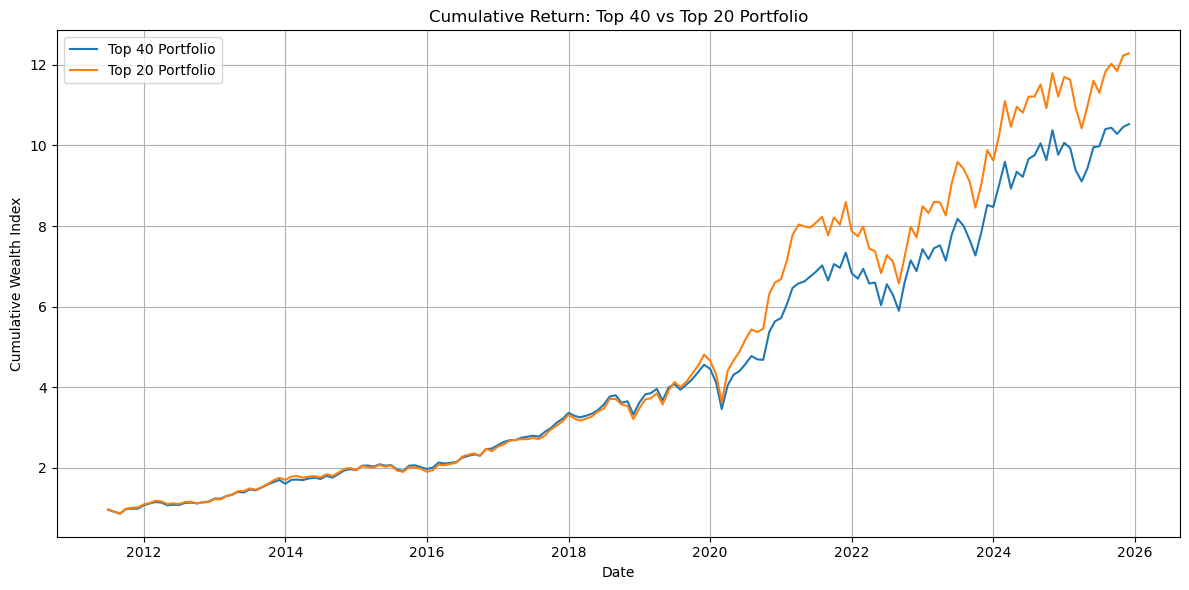

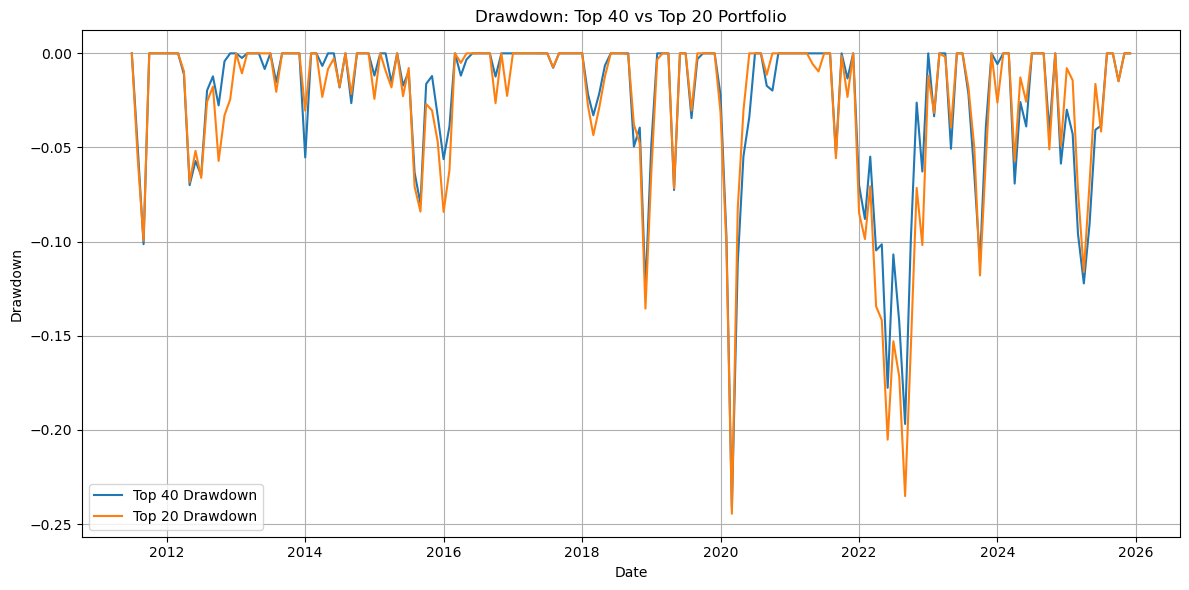

In [49]:
# ------------------------------------------------------------
# 5. Save performance summary
# ------------------------------------------------------------

performance_summary.to_csv("data/performance_summary_raw.csv", index=False)
performance_summary_formatted.to_csv("data/performance_summary_formatted.csv", index=False)

print("Saved performance summary files.")

# ------------------------------------------------------------
# 6. Create cumulative return series
# ------------------------------------------------------------

portfolio_returns["top40_cumulative"] = (
    1 + portfolio_returns["top40_return"]
).cumprod()

portfolio_returns["top20_cumulative"] = (
    1 + portfolio_returns["top20_return"]
).cumprod()

portfolio_returns.head()

# ------------------------------------------------------------
# 7. Plot cumulative wealth index
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top40_cumulative"],
    label="Top 40 Portfolio"
)

plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top20_cumulative"],
    label="Top 20 Portfolio"
)

plt.title("Cumulative Return: Top 40 vs Top 20 Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth Index")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("data/cumulative_return_top40_top20.png", dpi=300)

plt.show()

# ------------------------------------------------------------
# 8. Calculate drawdown series
# ------------------------------------------------------------

portfolio_returns["top40_running_max"] = portfolio_returns["top40_cumulative"].cummax()
portfolio_returns["top40_drawdown"] = (
    portfolio_returns["top40_cumulative"] / portfolio_returns["top40_running_max"] - 1
)

portfolio_returns["top20_running_max"] = portfolio_returns["top20_cumulative"].cummax()
portfolio_returns["top20_drawdown"] = (
    portfolio_returns["top20_cumulative"] / portfolio_returns["top20_running_max"] - 1
)

portfolio_returns[[
    "month",
    "top40_drawdown",
    "top20_drawdown"
]].head()

# ------------------------------------------------------------
# 9. Plot drawdown chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top40_drawdown"],
    label="Top 40 Drawdown"
)

plt.plot(
    portfolio_returns["month"],
    portfolio_returns["top20_drawdown"],
    label="Top 20 Drawdown"
)

plt.title("Drawdown: Top 40 vs Top 20 Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("data/drawdown_top40_top20.png", dpi=300)

plt.show()

In [51]:
# ------------------------------------------------------------
# 10. Save final portfolio return result
# ------------------------------------------------------------

portfolio_returns.to_csv("data/final_portfolio_returns_with_performance.csv", index=False)

print("Saved final portfolio return file.")



Saved final portfolio return file.


In [52]:
# ============================================================
# BENCHMARK COMPARISON AND ALPHA CALCULATION
# ============================================================

import statsmodels.api as sm

# ------------------------------------------------------------
# 1. Load portfolio returns
# ------------------------------------------------------------

portfolio_returns = pd.read_csv("data/top40_top20_monthly_portfolio_returns.csv")

portfolio_returns["month"] = pd.to_datetime(portfolio_returns["month"])
portfolio_returns = portfolio_returns.sort_values("month").copy()

portfolio_returns.head()

# ------------------------------------------------------------
# 2. Download SPY monthly adjusted prices as benchmark
# ------------------------------------------------------------

spy = yf.download(
    "SPY",
    start=portfolio_returns["month"].min(),
    end="2025-12-31",
    interval="1mo",
    auto_adjust=True,
    progress=False,
    multi_level_index=False
)

spy = spy.reset_index()

spy = spy[["Date", "Close"]].copy()
spy = spy.rename(columns={
    "Date": "month",
    "Close": "spy_adjusted_close"
})

spy["month"] = pd.to_datetime(spy["month"])
spy["benchmark_return"] = spy["spy_adjusted_close"].pct_change()

spy.head()

# ------------------------------------------------------------
# 3. Merge benchmark with portfolio returns
# ------------------------------------------------------------

portfolio_benchmark = portfolio_returns.merge(
    spy[["month", "benchmark_return"]],
    on="month",
    how="inner"
)

# Drop missing benchmark return
portfolio_benchmark = portfolio_benchmark.dropna(
    subset=["top40_return", "top20_return", "benchmark_return"]
).copy()

portfolio_benchmark.head()

# ------------------------------------------------------------
# 4. Performance function
# ------------------------------------------------------------

def calculate_performance(monthly_returns, strategy_name):
    monthly_returns = monthly_returns.dropna()

    n_months = len(monthly_returns)
    n_years = n_months / 12

    cumulative_return = (1 + monthly_returns).prod() - 1
    annualized_return = (1 + cumulative_return) ** (1 / n_years) - 1
    annualized_volatility = monthly_returns.std() * np.sqrt(12)
    sharpe_ratio = annualized_return / annualized_volatility

    wealth_index = (1 + monthly_returns).cumprod()
    running_max = wealth_index.cummax()
    drawdown = wealth_index / running_max - 1
    max_drawdown = drawdown.min()

    return {
        "Strategy": strategy_name,
        "Number of Months": n_months,
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# 5. Performance comparison
# ------------------------------------------------------------

top40_perf = calculate_performance(
    portfolio_benchmark["top40_return"],
    "Top 40 Portfolio"
)

top20_perf = calculate_performance(
    portfolio_benchmark["top20_return"],
    "Top 20 Portfolio"
)

spy_perf = calculate_performance(
    portfolio_benchmark["benchmark_return"],
    "SPY Benchmark"
)

performance_comparison = pd.DataFrame([
    top40_perf,
    top20_perf,
    spy_perf
])

performance_comparison


# ------------------------------------------------------------
# 6. Format performance comparison
# ------------------------------------------------------------

performance_comparison_formatted = performance_comparison.copy()

percent_cols = [
    "Cumulative Return",
    "Annualized Return",
    "Annualized Volatility",
    "Maximum Drawdown"
]

for col in percent_cols:
    performance_comparison_formatted[col] = (
        performance_comparison_formatted[col] * 100
    ).round(2).astype(str) + "%"

performance_comparison_formatted["Sharpe Ratio"] = (
    performance_comparison_formatted["Sharpe Ratio"].round(3)
)

performance_comparison_formatted

# ------------------------------------------------------------
# 7. Benchmark-adjusted returns
# ------------------------------------------------------------

portfolio_benchmark["top40_excess_vs_spy"] = (
    portfolio_benchmark["top40_return"] - portfolio_benchmark["benchmark_return"]
)

portfolio_benchmark["top20_excess_vs_spy"] = (
    portfolio_benchmark["top20_return"] - portfolio_benchmark["benchmark_return"]
)

top40_avg_monthly_excess = portfolio_benchmark["top40_excess_vs_spy"].mean()
top20_avg_monthly_excess = portfolio_benchmark["top20_excess_vs_spy"].mean()

top40_annualized_excess = top40_avg_monthly_excess * 12
top20_annualized_excess = top20_avg_monthly_excess * 12

print("Top 40 annualized excess return vs SPY:", round(top40_annualized_excess * 100, 2), "%")
print("Top 20 annualized excess return vs SPY:", round(top20_annualized_excess * 100, 2), "%")

# ------------------------------------------------------------
# 8. CAPM-style alpha calculation
# ------------------------------------------------------------

def calculate_alpha(portfolio_return, benchmark_return, strategy_name):
    data = pd.DataFrame({
        "portfolio_return": portfolio_return,
        "benchmark_return": benchmark_return
    }).dropna()

    y = data["portfolio_return"]
    X = data["benchmark_return"]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    monthly_alpha = model.params["const"]
    beta = model.params["benchmark_return"]
    annualized_alpha = monthly_alpha * 12

    return {
        "Strategy": strategy_name,
        "Monthly Alpha": monthly_alpha,
        "Annualized Alpha": annualized_alpha,
        "Beta": beta,
        "Alpha t-stat": model.tvalues["const"],
        "Alpha p-value": model.pvalues["const"],
        "R-squared": model.rsquared
    }

top40_alpha = calculate_alpha(
    portfolio_benchmark["top40_return"],
    portfolio_benchmark["benchmark_return"],
    "Top 40 Portfolio"
)

top20_alpha = calculate_alpha(
    portfolio_benchmark["top20_return"],
    portfolio_benchmark["benchmark_return"],
    "Top 20 Portfolio"
)

alpha_summary = pd.DataFrame([top40_alpha, top20_alpha])

alpha_summary

# ------------------------------------------------------------
# 9. Format alpha summary
# ------------------------------------------------------------

alpha_summary_formatted = alpha_summary.copy()

alpha_summary_formatted["Monthly Alpha"] = (
    alpha_summary_formatted["Monthly Alpha"] * 100
).round(3).astype(str) + "%"

alpha_summary_formatted["Annualized Alpha"] = (
    alpha_summary["Annualized Alpha"] * 100
).round(2).astype(str) + "%"

alpha_summary_formatted["Beta"] = alpha_summary_formatted["Beta"].round(3)
alpha_summary_formatted["Alpha t-stat"] = alpha_summary_formatted["Alpha t-stat"].round(3)
alpha_summary_formatted["Alpha p-value"] = alpha_summary_formatted["Alpha p-value"].round(4)
alpha_summary_formatted["R-squared"] = alpha_summary_formatted["R-squared"].round(3)

alpha_summary_formatted



Top 40 annualized excess return vs SPY: 3.57 %
Top 20 annualized excess return vs SPY: 4.75 %


,Strategy,Monthly Alpha,Annualized Alpha,Beta,Alpha t-stat,Alpha p-value,R-squared
0,Top 40 Portfolio,0.279%,3.34%,1.016,1.860,0.0646,0.836
1,Top 20 Portfolio,0.342%,4.1%,1.045,1.843,0.0671,0.778


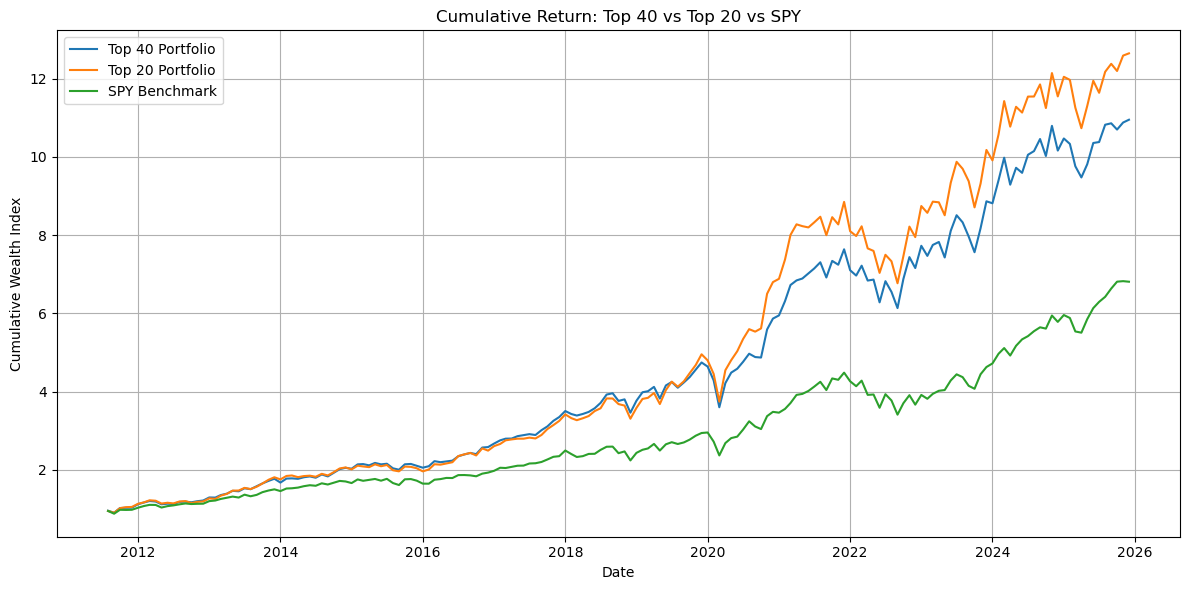

In [53]:
# ------------------------------------------------------------
# 11. Plot cumulative return against SPY
# ------------------------------------------------------------

portfolio_benchmark["top40_cumulative"] = (
    1 + portfolio_benchmark["top40_return"]
).cumprod()

portfolio_benchmark["top20_cumulative"] = (
    1 + portfolio_benchmark["top20_return"]
).cumprod()

portfolio_benchmark["spy_cumulative"] = (
    1 + portfolio_benchmark["benchmark_return"]
).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_benchmark["month"],
    portfolio_benchmark["top40_cumulative"],
    label="Top 40 Portfolio"
)

plt.plot(
    portfolio_benchmark["month"],
    portfolio_benchmark["top20_cumulative"],
    label="Top 20 Portfolio"
)

plt.plot(
    portfolio_benchmark["month"],
    portfolio_benchmark["spy_cumulative"],
    label="SPY Benchmark"
)

plt.title("Cumulative Return: Top 40 vs Top 20 vs SPY")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth Index")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("data/cumulative_return_with_spy.png", dpi=300)
plt.show()